# Wedge Models in Seismic Modeling

A **wedge model** is one of the most important synthetic models used in seismic interpretation and reservoir characterization.  
It represents a geological layer whose **thickness varies laterally**, typically thinning to zero at one end. This geometry mimics many real subsurface depositional environments such as **pinch-outs, clinoforms, and stratigraphic traps**.

Wedge models are widely used in geophysics to understand how **changes in layer thickness affect seismic reflections**. They are particularly useful for studying the **tuning effect**, which occurs when a thin layer becomes comparable to the wavelength of the seismic wave.

---

## Concept of a Wedge Model

In a typical wedge model:

- A **top horizon** represents the upper boundary of the layer.
- A **base horizon** represents the lower boundary.
- The **distance between these horizons changes laterally**, producing a wedge-shaped body.

As the layer thickness decreases toward the pinch-out point, the seismic reflections from the top and base interfaces begin to **interfere with each other**, producing amplitude variations known as **tuning effects**.

These amplitude variations are commonly used in seismic interpretation to infer:

- **Thin-bed thickness**
- **Reservoir presence**
- **Stratigraphic pinch-outs**

---

## Geological Significance

Wedge-shaped geometries occur naturally in many depositional environments, such as:

- **Deltaic deposits**
- **Submarine fans**
- **Shoreface deposits**
- **Stratigraphic pinch-outs**

Because these features are common hydrocarbon traps, wedge models are extremely useful for **testing seismic detectability of thin reservoirs**.

---

## Why Wedge Models Are Important in Geophysics

Wedge models help geophysicists understand several key seismic phenomena:

### 1. Seismic Tuning
When the layer thickness becomes smaller than approximately **one-quarter of the dominant seismic wavelength**, reflections from the top and base interfere constructively or destructively.  
This produces the **tuning thickness effect**, which strongly influences seismic amplitude.

### 2. Amplitude Variation with Thickness
By gradually changing the layer thickness across the model, wedge models allow us to study how **reflection amplitude changes with bed thickness**.

### 3. Synthetic Seismic Modeling
Wedge models are often used to generate **synthetic seismic sections** by:

1. Assigning rock properties (velocity and density)
2. Calculating **acoustic impedance**
3. Computing **reflection coefficients**
4. Convolving with a seismic wavelet

This workflow helps link **rock properties to seismic responses**.

---

## Types of Wedge Models

Different types of wedge geometries can be constructed depending on geological scenarios:

- **Layer-cake models** – horizontal layers with constant thickness  
- **Linear wedge models** – thickness changes linearly across distance  
- **Clinoform models** – sloping depositional surfaces  
- **Net-to-gross wedge models** – lithology varies laterally  

These models allow geoscientists to simulate realistic subsurface structures and evaluate how they would appear in seismic data.

---

## Application in Seismic Interpretation

Wedge models are commonly used for:

- Thin-bed analysis  
- Seismic tuning studies  
- Stratigraphic trap detection  
- Reservoir characterization  
- Seismic forward modeling  

By comparing synthetic wedge responses with real seismic data, geophysicists can better interpret subsurface geology and estimate reservoir thickness.

---

**In summary**, wedge models provide a powerful framework for understanding how geological thickness variations influence seismic reflections and amplitudes, making them an essential tool in seismic modeling and interpretation.

In [1]:
import matplotlib.pyplot as plt 
import bruges as bg

In [2]:
w,top,base,ref=bg.models.wedge()
w.shape

(100, 100)

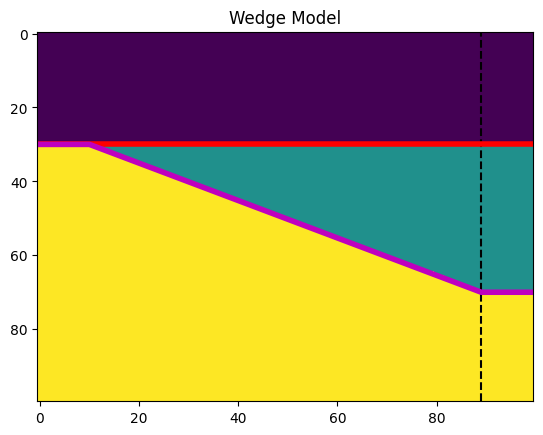

In [3]:
plt.imshow(w,interpolation="none",aspect="auto")
plt.axvline(ref,color="k",ls="--")
plt.plot(top,"r-",lw=4)
plt.plot(base,"m-",lw=4)
plt.title("Wedge Model")
plt.show()

### Function Output

The `wedge()` function returns four outputs:

- **w** – the 2D wedge model array  
- **top** – a 1D array representing the index of the wedge **top horizon** for each trace  
- **base** – a 1D array representing the index of the wedge **base horizon** for each trace  
- **ref** – the trace number where the wedge has a **reference thickness of 1**

By default, the model array contains integer labels **0, 1, and 2**, which represent different rock layers.

---

### Alternative Workflow

Instead of using integer labels and later assigning rock properties through indexing, we can directly create a **rock property model**.

This is done by passing the rock properties (e.g., **acoustic impedance, velocity, or density**) to the `wedge()` function using the **`strat` argument**.

This approach allows the wedge model to contain **actual physical rock properties rather than integer layer labels**.

In [4]:
import numpy as np
vps=np.array([2320,2350,2350,2360])
rhos=np.array([2650,2600,2620,2630])

impedence=vps*rhos

print("Impedence is" , impedence)
# impedence.shape

w,top,base,ref=bg.models.wedge(strat=impedence)
w.shape

Impedence is [6148000 6110000 6157000 6206800]


(100, 100)

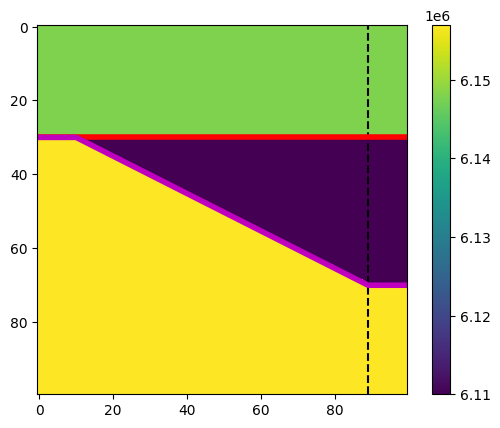

In [5]:
plt.imshow(w,interpolation="none")
plt.axvline(ref,color="k",ls="--")
plt.plot(top,"r-",lw=4)
plt.plot(base,"m-",lw=4)
plt.colorbar()

# A layered wedge model
-------------------------
Top layer (0)
------------------------

    1
     2
      1
       2
        1   ← wedge layers

-------------------------
Bottom layer (3)

In [6]:
w,top,base,ref=bg.models.wedge(depth=(100,600,100),
    width=(200,1600,200),
    strat=(0,(1,2,1,2,1),3),
    mode="linear"
)
w.shape

(800, 2000)

Text(0.5, 1.0, 'Layered wedge Model')

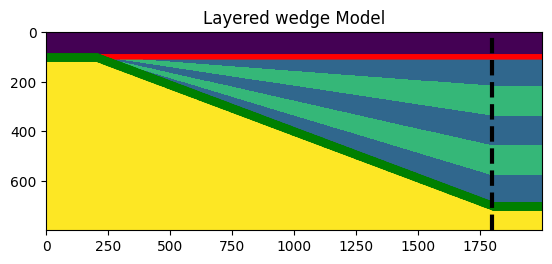

In [7]:
plt.imshow(w,interpolation="none")
plt.plot(top,"r-",lw=4)
plt.plot(base,"g+",lw=4)
plt.axvline(ref,ls="--",color="k",lw=3)
plt.title("Layered wedge Model")

In [8]:
w

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], shape=(800, 2000))

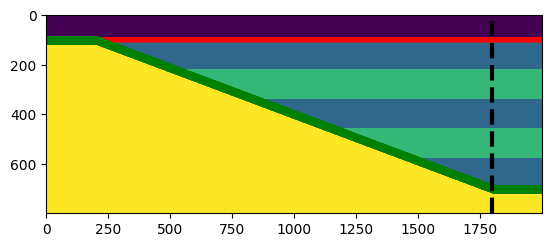

In [9]:
w,top,base,ref=bg.models.wedge(depth=(100,600,100),
    width=(200,1600,200),
    strat=(0,(1,2,1,2,1),3),
    mode="linear",
    conformance="top"
)
w.shape
plt.imshow(w,interpolation="none")
plt.plot(top,"r-",lw=4)
plt.plot(base,"g+",lw=4)
plt.axvline(ref,ls="--",color="k",lw=3)


In [10]:
depth=np.arange(100,600,100)
depth

array([100, 200, 300, 400, 500])

# A layer-cake model
Here we can provide the minimum and maximum thickness of the wedge

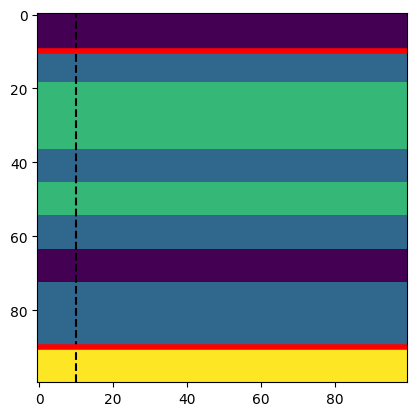

In [11]:
w, top, base, ref = bg.models.wedge(depth=(10., 80, 10),
                                    width=(10, 80, 10),
                                    strat=(0, (1, 2, 2, 1, 2, 1, 0, 1, 1,), 3),  # Floats in the wedge
                                    thickness=(1, 1),
                                    mode='linear',
                                    )

plt.imshow(w, interpolation='none')
plt.axvline(ref, color='k', ls='--')
plt.plot(top, 'r-', lw=4)
plt.plot(base, 'r-', lw=4)
plt.show()

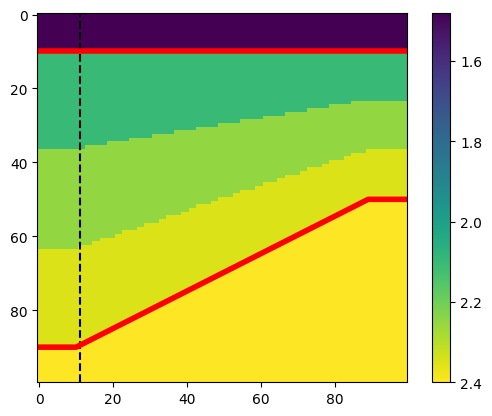

In [12]:
w, top, base, ref = bg.models.wedge(depth=(10., 80, 10),
                                    width=(10, 80, 10),
                                    strat=(1.48, (2.10, 2.25, 2.35), 2.40),  # Floats in the wedge.
                                    thickness=(1, 0.5),
                                    mode='linear',
                                    )

plt.imshow(w, interpolation='none')
plt.axvline(ref, color='k', ls='--')
plt.plot(top, 'r-', lw=4)
plt.plot(base, 'r-', lw=4)
cb = plt.colorbar()
cb.ax.invert_yaxis()
plt.show()

# Top and bottom conformance

The layers in the wedge can also be top or bottom conforming,rather than proportionally adjusted.

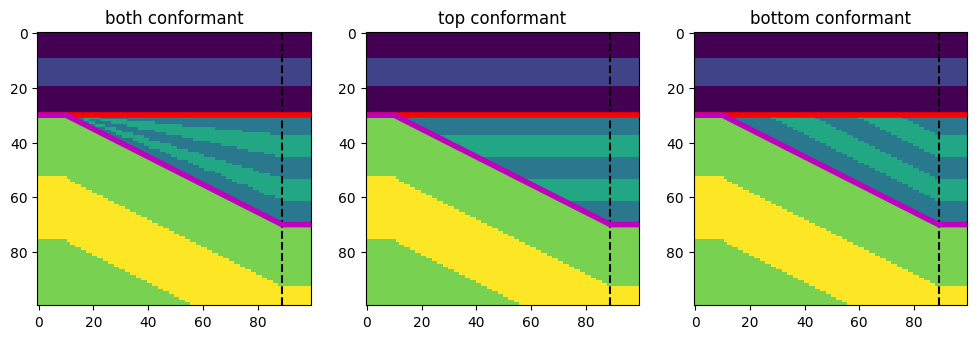

In [13]:
confs=["both","top","bottom"]

fig,axs=plt.subplots(ncols=len(confs),figsize=(12,4))

for ax ,conf in zip(axs,confs):

    w,top,base,ref=bg.models.wedge(
        strat=((0,1,0),(2,3,2,3,2),(4,5,4)),
        conformance=conf
    )
    ax.imshow(w,interpolation="none")
    ax.axvline(ref,color="k",ls="--")
    ax.plot(top,"r-",lw=4)
    ax.plot(base,"m-",lw=4)
    ax.set_title(f"{conf} conformant")

plt.show()

    


# Different "wedge" shapes

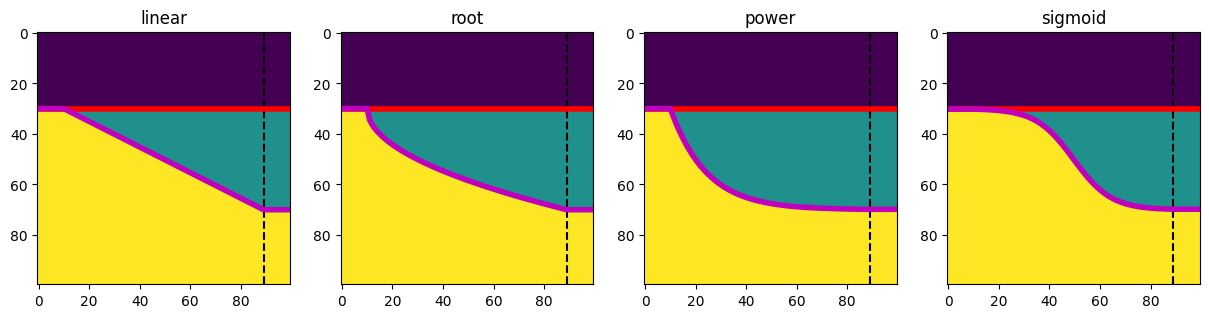

In [14]:
modes=["linear","root","power","sigmoid"]

fig,axs=plt.subplots(ncols=len(modes),figsize=(15,5))

for ax, mode in zip(axs,modes):
    w,top,base,ref=bg.models.wedge(mode=mode)
    ax.imshow(w,interpolation="none")
    ax.axvline(ref,color="k",ls="--")
    ax.plot(top,"r-",lw=4)
    ax.plot(base,"m-",lw=4)
    ax.set_title(mode)

plt.show()
    


## Create my own wedge function

In [15]:
def wavy(start,stop,num):
    """ 
    Custom wedge shape
    """
    x=np.linspace(0,10*np.pi,num)

    y=np.sin(x)+x
    #Normalize to 0-1
    y_=(y-np.min(y))/(np.max(y)-np.min(y))

    #Scale to the required output
    return min(start,stop)+abs(stop-start)*y_



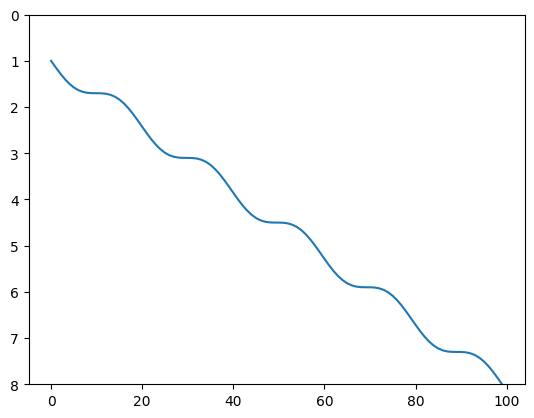

In [16]:
# The wedge function will pass 'left' and 'right' thicknesses.
# You only need to worry about the case where left < right.
left, right = 1, 8
y = wavy(left, right, 100)

plt.plot(y)
plt.ylim(right, 0)
plt.show()

#### Make a model using that function

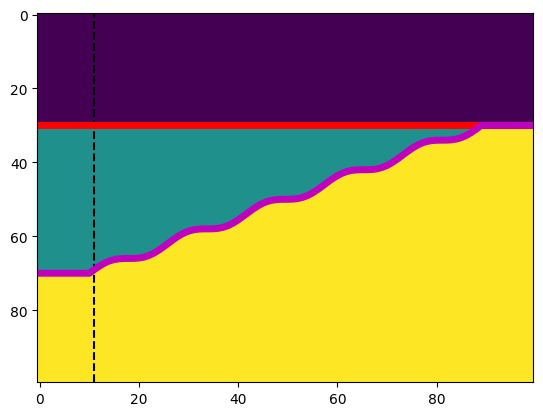

In [17]:
w,top,base,ref=bg.models.wedge(mode=wavy, thickness=(1,0))
plt.imshow(w,interpolation="none",aspect="auto")
plt.axvline(ref,ls="--",color="k")
plt.plot(top,"r-",lw=5)
plt.plot(base,"m-",lw=5)



Varying net:gross across breadth

In [18]:
w, top, base, ref = bg.models.wedge(strat=(0, (1, 2, 1, 1, 2, 1), 3),  # Binary wedge.
                                    breadth=100)

w.shape, top.shape, base.shape, ref

((100, 100, 100), (100, 100), (100, 100), np.int64(89))

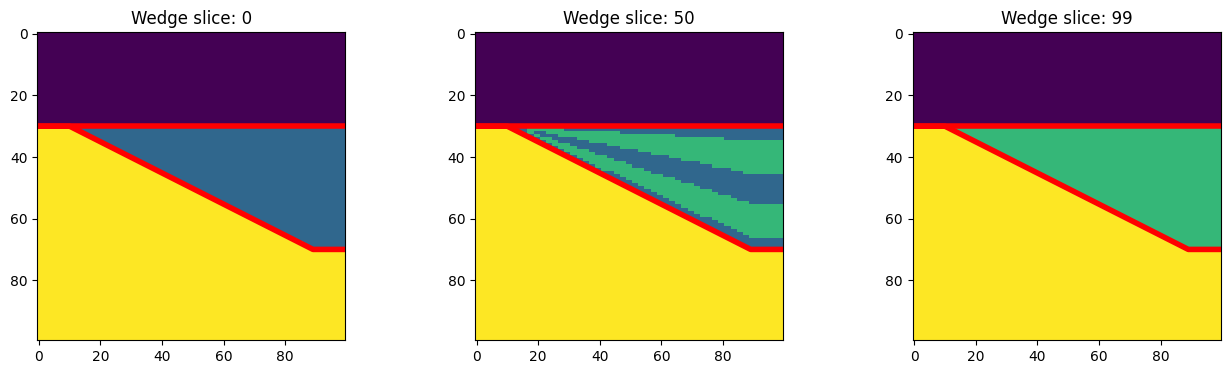

In [19]:
slices = [0, 50, 99]

fig, axs = plt.subplots(ncols=len(slices), figsize=(16, 4))
for ax, slic in zip(axs, slices):
    ax.imshow(w[..., slic], interpolation='none')
    ax.plot(top[:, slic], 'r-', lw=4)
    ax.plot(base[:, slic], 'r-', lw=4)
    ax.set_title(f"Wedge slice: {slic}")
plt.show()

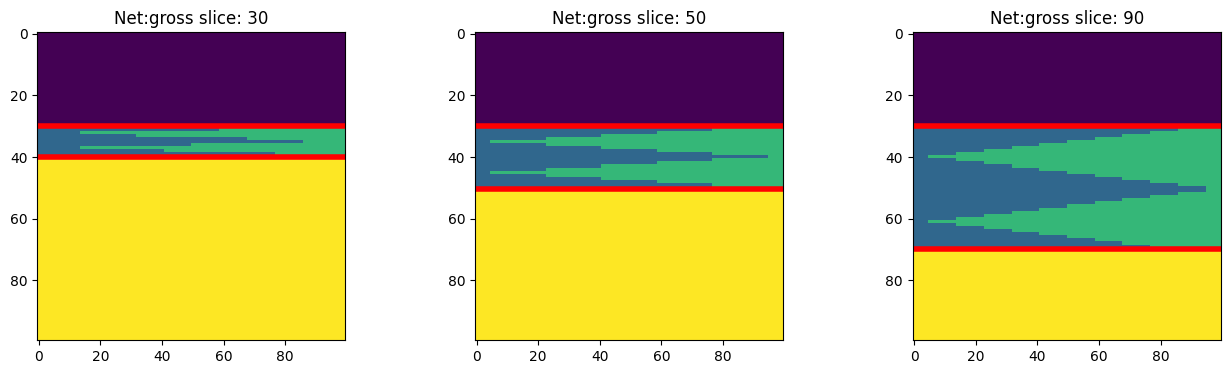

In [20]:
slices = [30, 50, 90]

fig, axs = plt.subplots(ncols=len(slices), figsize=(16, 4))
for ax, slic in zip(axs, slices):
    ax.imshow(w[:, slic], interpolation='none')
    ax.plot(top[slic], 'r-', lw=4)
    ax.plot(base[slic], 'r-', lw=4)
    ax.set_title(f"Net:gross slice: {slic}")
plt.show()


In [21]:
vps = np.array([2320, 2350, 2350, 2370])
rhos = np.array([2650, 2600, 2620, 2610])

vp = vps[w]
rho = rhos[w]

rc = bg.reflection.acoustic_reflectivity(vp, rho)


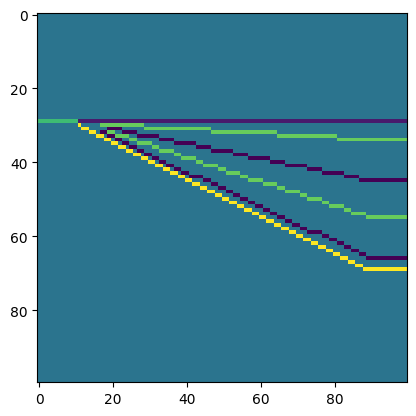

In [22]:
plt.imshow(rc[:, :, 50])

In [23]:
ricker, t = bg.filters.ricker(duration=0.064, dt=0.001, f=40)

syn = bg.filters.convolve(rc, ricker, axis=0)  # Time is on the first axis.
syn.shape

(100, 100, 100)

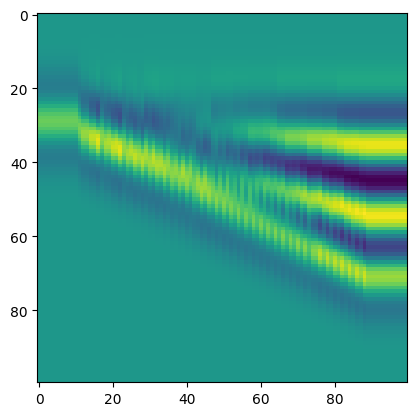

In [24]:
plt.imshow(syn[:, :, 50])

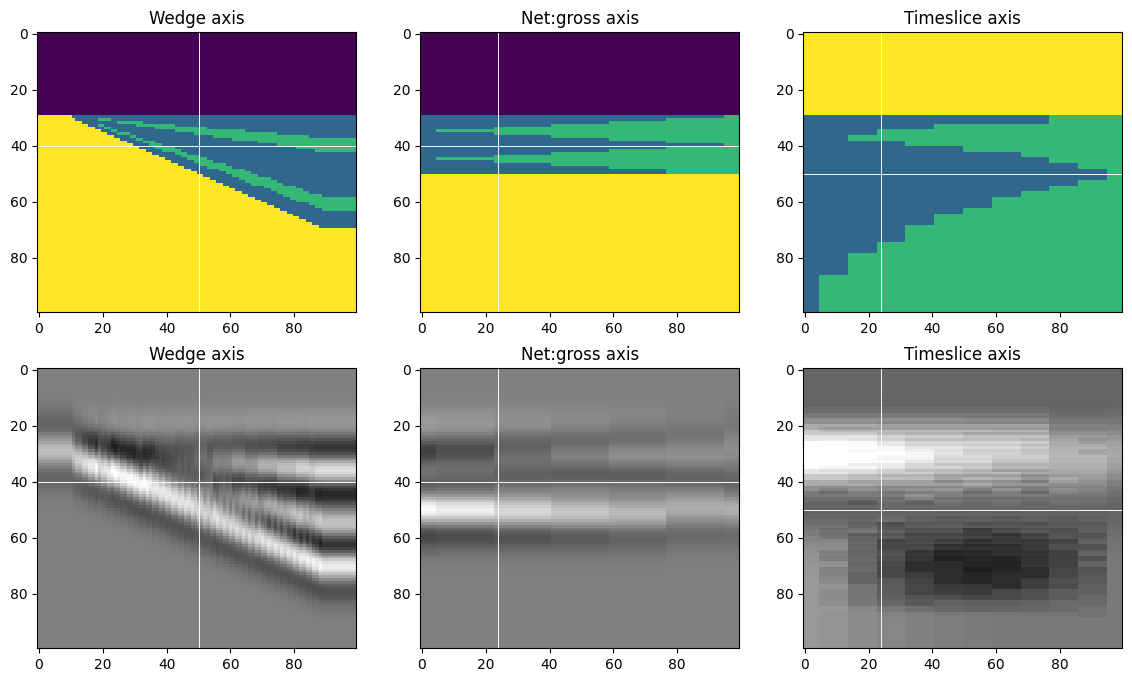

In [25]:
ma = np.percentile(syn, 99.9)
vols, cmaps = [w, syn], ['viridis', 'gray']

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(14, 8))
for row, vol, cm in zip(axs, vols, cmaps):
    row[0].imshow(vol[:, :, 24], aspect='auto', interpolation='none', cmap=cm, vmin=-ma if vol is syn else None, vmax=ma if vol is syn else None)
    row[0].axhline(40, c='w', lw=0.67)
    row[0].axvline(50, c='w', lw=0.67)
    row[0].set_title(f"Wedge axis")
    row[1].imshow(vol[:, 50, :], aspect='auto', interpolation='none', cmap=cm, vmin=-ma if vol is syn else None, vmax=ma if vol is syn else None)
    row[1].axhline(40, c='w', lw=0.67)
    row[1].axvline(24, c='w', lw=0.67)
    row[1].set_title(f"Net:gross axis")
    row[2].imshow(vol[40, :, :], aspect='auto', interpolation='none', cmap=cm, vmin=0 if vol is w else -ma, vmax=ma if vol is syn else None)
    row[2].axhline(50, c='w', lw=0.67)
    row[2].axvline(24, c='w', lw=0.67)
    row[2].set_title(f"Timeslice axis")
plt.show()


# Models from well logs
We can pass in arrays as strat and they will be used as the values in the model layers.

We’ll start by loading a CSV file of a well log and dissecting it into three zones that we can pass in as strat. Welly would but useful for this, but we can also select these segments using conditions on the key depth boundaries.

Well load the well log as a 2D numpy array, and then pull out the depths, p-sonic (slowness) dt, and density rhob

In [26]:
import lasio as ls
import pandas as pd 
log_data=ls.read("/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/Data/Gorgonichthys_1_suite3_supercombo_log.las")
well_data=log_data.df().reset_index()

In [27]:
well_data.head()

,DEPTH,AT10,AT20,AT30,AT60,AT90,CALI,DRHO,DT2,DTCO,DTSM,GR,PEF,PR,RHOB,RT,SPHI,TNPH,VPVS
0,4775.7588,4.675,4.591,4.656,4.755,4.827,8.041,0.154,167.465,79.789,167.465,195.824,6.827,0.353,2.749,210.536,0.186,0.434,2.099
1,4775.6064,4.675,4.591,4.655,4.755,4.827,8.041,0.154,167.465,79.789,167.465,195.824,6.827,0.353,2.749,4.801,0.186,0.434,2.099
2,4775.4540,4.675,4.591,4.655,4.756,4.827,8.041,0.154,167.465,79.789,167.465,195.824,6.827,0.353,2.749,4.801,0.186,0.434,2.099
3,4775.3016,4.675,4.591,4.655,4.756,4.827,8.041,0.154,167.465,79.789,167.465,195.824,6.827,0.353,2.749,4.801,0.186,0.434,2.099
4,4775.1492,4.675,4.591,4.655,4.756,4.827,8.041,0.154,167.465,79.789,167.465,195.824,6.827,0.353,2.749,4.801,0.186,0.434,2.099


In [28]:
well_data.columns

Index(['DEPTH', 'AT10', 'AT20', 'AT30', 'AT60', 'AT90', 'CALI', 'DRHO', 'DT2',
       'DTCO', 'DTSM', 'GR', 'PEF', 'PR', 'RHOB', 'RT', 'SPHI', 'TNPH',
       'VPVS'],
      dtype='object')

In [29]:
depth,dt,rhob=well_data.iloc[:,0],well_data.iloc[:,8],well_data.iloc[:,14]


In [30]:

table = pd.DataFrame({
    "Depth": depth,
    "DT": dt,
    "RHOB": rhob
})
print(table)

          Depth       DT   RHOB
0     4775.7588  167.465  2.749
1     4775.6064  167.465  2.749
2     4775.4540  167.465  2.749
3     4775.3016  167.465  2.749
4     4775.1492  167.465  2.749
...         ...      ...    ...
5683  3909.6696  143.363  1.794
5684  3909.5172  143.363  1.802
5685  3909.3648  143.363  1.804
5686  3909.2124  143.363  1.804
5687  3909.0600  143.363  1.804

[5688 rows x 3 columns]


### Calculate impedence

In [40]:
impedance=(1e6/dt)*rhob

In [36]:
datum = 4700
top   = 4500
base  = 4300
floor = 4100



In [41]:
log_upper = impedance[(depth < datum) & (depth >= top)]
log_wedge = impedance[(depth < top) & (depth >= base)]
log_lower = impedance[(depth < base) & (depth >= floor)]

upper_depths = depth[(depth < datum) & (depth >= top)]
wedge_depths = depth[(depth < top) & (depth >= base)]
lower_depths = depth[(depth < base) & (depth >= floor)]


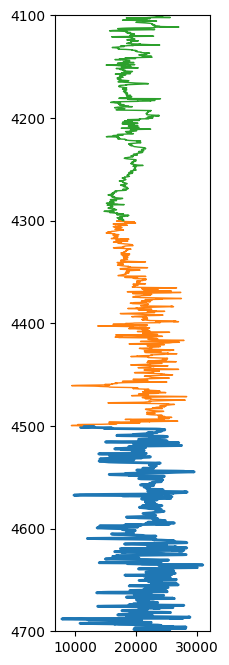

In [47]:
plt.figure(figsize=(2, 8))
plt.plot(log_upper, upper_depths, lw=2)
plt.plot(log_wedge, wedge_depths, lw=1)
plt.plot(log_lower, lower_depths, lw=1)
plt.ylim(floor, datum)
plt.gca().invert_yaxis()
plt.show()

In [48]:
w, top, base, ref = bg.models.wedge(depth=(400, 208, 400),
                                    width=(20, 260, 20),
                                    strat=(log_upper, log_wedge, log_lower),
                                    mode='sigmoid', conformance='bottom',
                                    thickness=(0, 2)
                                    )

In [49]:
log = w[:, ref]

# Make a scaled version of the log for the section plot.
log_ = (log - np.mean(log)) / np.std(log)
depth = np.arange(len(log))
sf = 2.5
log_bias = np.ptp(log_)



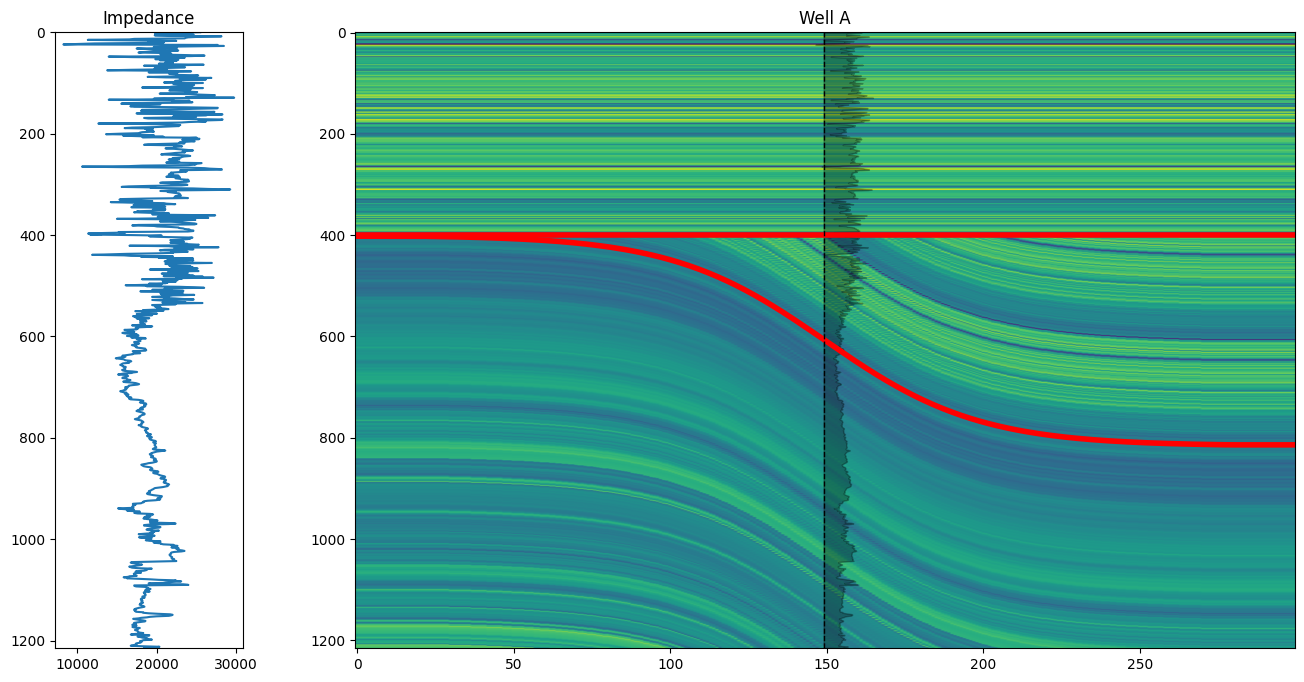

In [50]:


fig, axs = plt.subplots(figsize=(16, 8), ncols=2, gridspec_kw={'width_ratios': (1, 5)})

axs[0].plot(log, depth)
axs[0].set_ylim(depth[-1], depth[0])
axs[0].set_title('Impedance')

im=axs[1].imshow(w, aspect='auto', cmap='viridis')
axs[1].plot(top, 'r-', lw=4)
axs[1].plot(base, 'r-', lw=4)
axs[1].fill_betweenx(depth, ref + log_bias + (sf*log_), ref, color='k', alpha=0.3)
# axs[1].plot(ref + log_bias + (sf*log), depth, c='k', lw=1)
axs[1].axvline(ref, color='k', ls='--', lw=1)
axs[1].set_title('Well A')

plt.show()

